In [9]:
import mujoco as mj
from pathlib import Path
import mujoco.viewer
import time

In [10]:


XML_RELATIVE_PATH = Path("assets/mujoco_practice.xml")

def resolve_model_path(relative_path: Path) -> Path:
    """Busca el XML sin depender de desde donde se lanzo Jupyter."""
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontro '{relative_path}' (cwd actual: {Path.cwd()}). "
        "Corre el notebook desde la raiz del proyecto ERP, o ajusta XML_RELATIVE_PATH."
    )

model_path = resolve_model_path(XML_RELATIVE_PATH)
print(f"Cargando modelo MuJoCo desde: {model_path}")

model = mj.MjModel.from_xml_path(str(model_path))
data = mj.MjData(model)

print(f"Modelo cargado OK -> bodies: {model.nbody}, joints: {model.njnt}, geoms: {model.ngeom}")


Cargando modelo MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\assets\mujoco_practice.xml
Modelo cargado OK -> bodies: 5, joints: 3, geoms: 4


In [11]:
import numpy as np

mj.mj_resetData(model, data)
tip_id = mj.mj_name2id(model, mj.mjtObj.mjOBJ_SITE, "tip")

log_time = []
log_qpos = []
log_tip_pos = []

with mujoco.viewer.launch_passive(model, data) as viewer:
    while viewer.is_running():
        step_start = time.time()

        # --- your code goes here, e.g. data.ctrl[:] = ... ---
        mujoco.mj_step(model, data)
        # ------------------------------------------------------

        # loguea el estado de este paso
        log_time.append(data.time)
        log_qpos.append(data.qpos.copy())
        log_tip_pos.append(data.site_xpos[tip_id].copy())

        viewer.sync()

        # keep it running roughly in real time
        time_until_next_step = model.opt.timestep - (time.time() - step_start)
        if time_until_next_step > 0:
            time.sleep(time_until_next_step)

# convierte los logs a arrays una vez cerrada la ventana del viewer
log_time = np.array(log_time)
log_qpos = np.array(log_qpos)
log_tip_pos = np.array(log_tip_pos)

print(f"Se registraron {len(log_time)} pasos ({log_time[-1] if len(log_time) else 0:.2f}s)")


Se registraron 6875 pasos (13.75s)


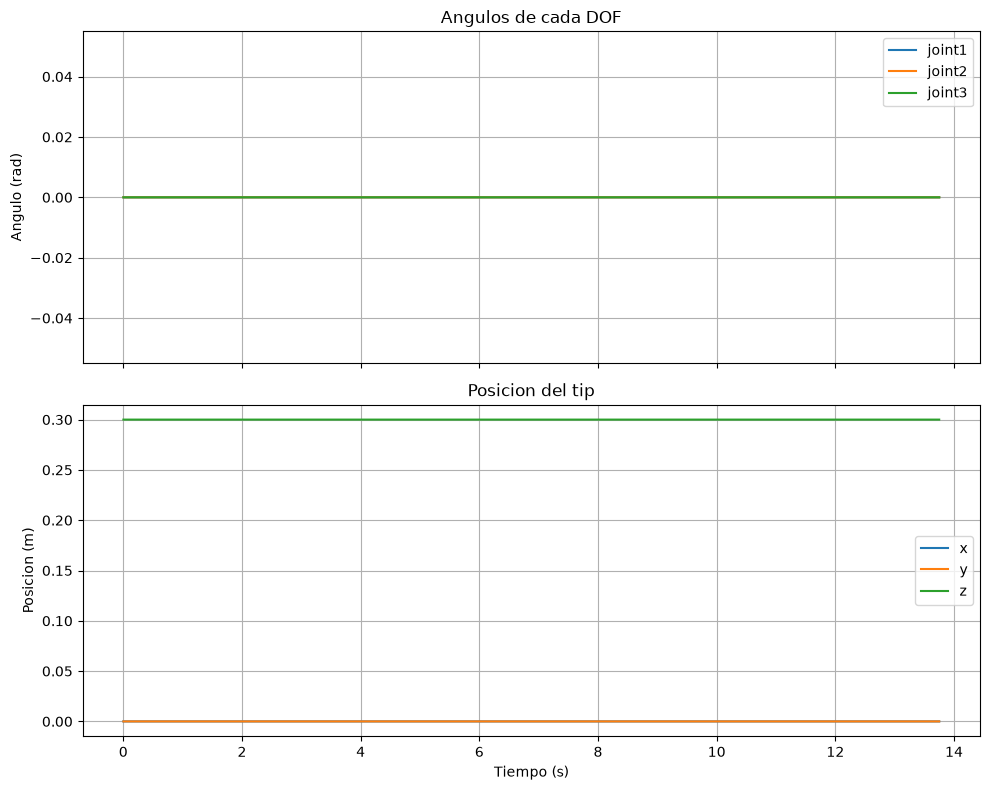

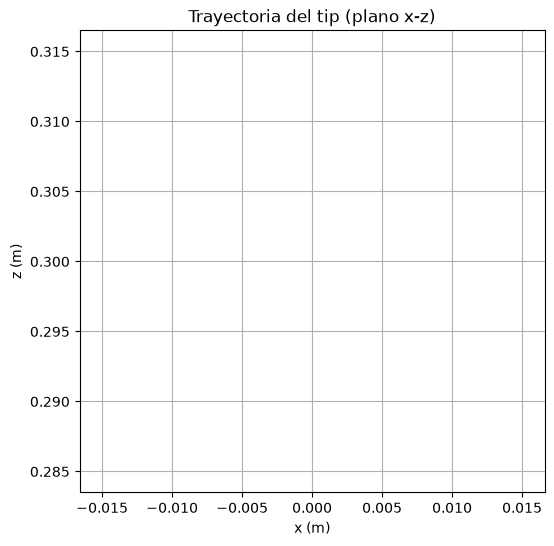

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Angulos de cada DOF
for j in range(model.nq):
    axes[0].plot(log_time, log_qpos[:, j], label=f"joint{j + 1}")
axes[0].set_ylabel("Angulo (rad)")
axes[0].set_title("Angulos de cada DOF")
axes[0].legend()
axes[0].grid(True)

# Posicion del tip (x, y, z)
axes[1].plot(log_time, log_tip_pos[:, 0], label="x")
axes[1].plot(log_time, log_tip_pos[:, 1], label="y")
axes[1].plot(log_time, log_tip_pos[:, 2], label="z")
axes[1].set_xlabel("Tiempo (s)")
axes[1].set_ylabel("Posicion (m)")
axes[1].set_title("Posicion del tip")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Trayectoria del tip en el plano x-z (el pendulo rota alrededor del eje y)
plt.figure(figsize=(6, 6))
plt.plot(log_tip_pos[:, 0], log_tip_pos[:, 2])
plt.xlabel("x (m)")
plt.ylabel("z (m)")
plt.title("Trayectoria del tip (plano x-z)")
plt.axis("equal")
plt.grid(True)
plt.show()
